In [1]:
# Cell 1 - run once, loading data is slow
import pandas as pd
raw_business = pd.read_parquet("../../data/business_y_removed.parquet")
raw_checkin = pd.read_parquet("../../data/checkin.parquet")
raw_review = pd.read_parquet("../../data/review-001.parquet")
raw_tips = pd.read_parquet("../../data/tip.parquet")
raw_user = pd.read_parquet("../../data/user-002.parquet")


In [2]:
import numpy as np

In [3]:
pd.set_option('display.max_columns', None)

CLEANING RAW DATAFRAMES TO REMOVE NON-FOOD RELATED PLACES

In [4]:
food_keywords = [
    'Restaurant', 'Food', 'Cafe', 'Coffee', 'Bakery', 
    'Bar', 'Pub', 'Diner', 'Eatery', 'Bistro', 
    'Brewery', 'Pizzeria', 'Sushi', 'Steakhouse', 'Deli'
]
pattern = '|'.join(food_keywords)
business = raw_business[raw_business['categories'].str.contains(pattern, na=False, case=False)]
business = business.dropna(subset=['is_open'])
business = business.reset_index(drop=True)
business['is_open'].value_counts(normalize=True)

is_open
1.0    0.703036
0.0    0.296964
Name: proportion, dtype: float64

In [5]:
restaurant_ids = set(business["business_id"])
checkins = raw_checkin[raw_checkin['business_id'].isin(restaurant_ids)]
reviews = raw_review[raw_review['business_id'].isin(restaurant_ids)]
tips = raw_tips[raw_tips['business_id'].isin(restaurant_ids)]


restaurant_user_ids = set(reviews['user_id'])
users = raw_user[raw_user['user_id'].isin(restaurant_user_ids)]

----------------------------------------------------------------------------------------------------------------------------------------------------------------

CHECKING BEFORE AND AFTER SHAPES OF DATAFRAMES

In [6]:
raw_business.shape, raw_checkin.shape, raw_review.shape, raw_tips.shape, raw_user.shape

((150346, 14), (131930, 2), (6990280, 9), (908915, 5), (1987897, 22))

In [7]:
business.shape, checkins.shape, reviews.shape, tips.shape, users.shape

((56293, 14), (54982, 2), (4239750, 9), (598767, 5), (1351573, 22))

----------------------------------------------------------------------------------------------------------------------------------------------------------------

CHECKING CORRELATION OF VARIOUS SERIES WITH IS_OPEN ATTRIBUTE

In [8]:
from datetime import datetime

# Convert date to datetime
reviews['date'] = pd.to_datetime(reviews['date'])

# Reference point for recency calculations
reference_date = reviews['date'].max()

# Aggregate all review features per business
review_features = reviews.groupby('business_id').agg(
    review_count_actual   = ('review_id', 'count'),
    avg_review_stars      = ('stars', 'mean'),
    std_review_stars      = ('stars', 'std'),        # consistency of ratings
    total_useful          = ('useful', 'sum'),
    total_funny           = ('funny', 'sum'),
    total_cool            = ('cool', 'sum'),
    first_review_date     = ('date', 'min'),
    last_review_date      = ('date', 'max'),
).reset_index()

# Recency — days since last review
review_features['days_since_last_review'] = (
    reference_date - review_features['last_review_date']
).dt.days

# Lifespan — how long has this business been reviewed
review_features['review_lifespan_days'] = (
    review_features['last_review_date'] - review_features['first_review_date']
).dt.days

# Velocity — average reviews per month
review_features['reviews_per_month'] = (
    review_features['review_count_actual'] / 
    (review_features['review_lifespan_days'] / 30)
).replace([float('inf')], 0)  # handle businesses with only 1 review

# Drop raw date columns — model doesn't need them
review_features = review_features.drop(
    columns=['first_review_date', 'last_review_date']
)

temp = review_features[['business_id', 'days_since_last_review']].merge(
    business[['business_id', 'is_open']], 
    on='business_id'
)

# Correlation
print(temp[['days_since_last_review', 'is_open']].corr()['is_open'])

days_since_last_review   -0.738546
is_open                   1.000000
Name: is_open, dtype: float64


In [9]:
# Parse the comma-separated timestamps
checkins['date'] = checkins['date'].str.split(', ')
checkins['date'] = checkins['date'].apply(
    lambda x: pd.to_datetime(x, errors='coerce')
)

# Now engineer features
reference_date = pd.Timestamp(reviews['date'].max())

checkin_features = checkins.apply(lambda row: pd.Series({
    'business_id'              : row['business_id'],
    'total_checkins'           : len(row['date']),
    'days_since_last_checkin'  : (reference_date - max(row['date'])).days,
    'checkin_lifespan_days'    : (max(row['date']) - min(row['date'])).days,
    'checkins_per_month'       : len(row['date']) / 
                                 max((max(row['date']) - min(row['date'])).days / 30, 1)
}), axis=1)

temp2 = checkin_features[['business_id', 'days_since_last_checkin']].merge(
    business[['business_id', 'is_open']],
    on='business_id'
)

print(temp2[['days_since_last_checkin', 'is_open']].corr()['is_open'])

days_since_last_checkin   -0.686343
is_open                    1.000000
Name: is_open, dtype: float64


In [10]:
tips['date'] = pd.to_datetime(tips['date'])

tip_features = tips.groupby('business_id').agg(
    total_tips            = ('user_id', 'count'),
    total_compliments     = ('compliment_count', 'sum'),
    days_since_last_tip   = ('date', lambda x: (reference_date - x.max()).days),
    tip_lifespan_days     = ('date', lambda x: (x.max() - x.min()).days),
).reset_index()

tip_features['tips_per_month'] = (
    tip_features['total_tips'] /
    (tip_features['tip_lifespan_days'] / 30)
).replace([float('inf')], 0)

temp3 = tip_features[['business_id', 'days_since_last_tip']].merge(
    business[['business_id', 'is_open']],
    on='business_id'
)

print(temp3[['days_since_last_tip', 'is_open']].corr()['is_open'])

days_since_last_tip   -0.470394
is_open                1.000000
Name: is_open, dtype: float64


In [11]:
# Parse elite — count how many years they've been elite
users['elite_years'] = users['elite'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) and x != '' and x != 'None' else 0
)

# Parse yelping_since to get user experience in days
users['yelping_since'] = pd.to_datetime(users['yelping_since'])
users['yelping_experience_days'] = (reference_date - users['yelping_since']).dt.days

# Keep only what we need
user_features = users[[
    'user_id', 'elite_years', 'fans', 
    'useful', 'review_count', 'yelping_experience_days'
]]

# Join users onto reviews
reviews_with_users = reviews[['business_id', 'user_id']].merge(
    user_features, on='user_id', how='left'
)

# Aggregate per business
business_user_features = reviews_with_users.groupby('business_id').agg(
    avg_reviewer_elite_years    = ('elite_years', 'mean'),
    pct_elite_reviewers         = ('elite_years', lambda x: (x > 0).mean()),
    avg_reviewer_fans           = ('fans', 'mean'),
    avg_reviewer_useful         = ('useful', 'mean'),
    avg_reviewer_experience     = ('yelping_experience_days', 'mean'),
    unique_reviewers            = ('user_id', 'nunique'),
).reset_index()

temp4 = business_user_features[['business_id', 'avg_reviewer_fans', 
                                  'avg_reviewer_experience',
                                  'unique_reviewers']].merge(
    business[['business_id', 'is_open']],
    on='business_id'
)

print(temp4[['avg_reviewer_fans', 'avg_reviewer_experience', 
             'unique_reviewers', 'is_open']].corr()['is_open'])

avg_reviewer_fans         -0.032073
avg_reviewer_experience   -0.496340
unique_reviewers           0.097710
is_open                    1.000000
Name: is_open, dtype: float64


----------------------------------------------------------------------------------------------------------------------------------------------------------------

REMOVING NON-FOOD RELATED ATTRIBUTES FROM BUSINESS AND FINDING TOP ATTRIBUTES

In [12]:
import ast

def parse_attributes(attr):
    if attr is None or attr == 'None':
        return {}
    if isinstance(attr, str):
        try:
            return ast.literal_eval(attr)
        except:
            return {}
    return attr

business['attributes_parsed'] = business['attributes'].apply(parse_attributes)
print(f"After parse_attributes: {business.shape}")

After parse_attributes: (56293, 15)


In [13]:
bool_attrs = [
    'BikeParking', 'BusinessAcceptsCreditCards', 'Caters',
    'DogsAllowed', 'DriveThru', 'GoodForKids', 
    'HappyHour', 'HasTV', 'OutdoorSeating', 'RestaurantsDelivery', 'RestaurantsGoodForGroups',
    'RestaurantsReservations', 'RestaurantsTableService', 'RestaurantsTakeOut', 
    'WheelchairAccessible'
]

def parse_bool(val):
    if val is None or val == 'None':
        return np.nan
    if isinstance(val, bool):
        return int(val)
    if isinstance(val, str):
        return 1 if val.strip().lower() == 'true' else 0
    return np.nan

for attr in bool_attrs:
    business[f'attr_{attr}'] = business['attributes_parsed'].apply(
        lambda x: parse_bool(x.get(attr))
    )

business['attr_PriceRange'] = business['attributes_parsed'].apply(
    lambda x: int(x['RestaurantsPriceRange2']) 
    if x.get('RestaurantsPriceRange2') not in [None, 'None'] 
    else np.nan
)
print(f"After bool and numeric attrs: {business.shape}")

After bool and numeric attrs: (56293, 31)


In [14]:
cat_attrs = ['Alcohol', 'WiFi', 'NoiseLevel', 'RestaurantsAttire']

def clean_cat(val):
    if val is None or val == 'None':
        return np.nan
    val = str(val).strip()
    val = val.replace("u'", "").replace("'", "")
    return val.lower()

for attr in cat_attrs:
    cleaned = business['attributes_parsed'].apply(
        lambda x: clean_cat(x.get(attr))
    )
    dummies = pd.get_dummies(cleaned, prefix=f'attr_{attr}', dummy_na=False).astype(int)
    business = pd.concat([business, dummies], axis=1)

business = business.loc[:, ~business.columns.duplicated()]
print(f"After categorical attrs: {business.shape}")

After categorical attrs: (56293, 44)


In [15]:
open_restaurants = business[business['is_open'] == 1]
closed_restaurants = business[business['is_open'] == 0]

attr_cols = [c for c in business.columns if c.startswith('attr_')]

ratio_analysis = pd.DataFrame({
    'open_rate'   : open_restaurants[attr_cols].mean(),
    'closed_rate' : closed_restaurants[attr_cols].mean(),
})

ratio_analysis['difference'] = ratio_analysis['open_rate'] - ratio_analysis['closed_rate']
print(ratio_analysis.sort_values('difference', ascending=False).to_string())

                                 open_rate  closed_rate  difference
attr_DriveThru                    0.672620     0.261637    0.410983
attr_RestaurantsDelivery          0.728644     0.370462    0.358181
attr_HasTV                        0.820390     0.644481    0.175910
attr_GoodForKids                  0.860972     0.804488    0.056484
attr_WheelchairAccessible         0.921207     0.899765    0.021443
attr_WiFi_free                    0.352587     0.338278    0.014309
attr_OutdoorSeating               0.488679     0.479600    0.009079
attr_RestaurantsAttire_formal     0.000935     0.000957   -0.000022
attr_WiFi_paid                    0.003891     0.005324   -0.001433
attr_NoiseLevel_loud              0.039367     0.041933   -0.002566
attr_BusinessAcceptsCreditCards   0.959804     0.964370   -0.004566
attr_RestaurantsAttire_dressy     0.008439     0.017407   -0.008968
attr_NoiseLevel_very_loud         0.012937     0.022552   -0.009615
attr_RestaurantsTakeOut           0.917917     0

MERGING INTO A FINAL DATAFRAME

In [16]:
final_df = business[['business_id', 'is_open', 'stars', 'review_count', 
                      'latitude', 'longitude'] + attr_cols].copy()

final_df = final_df.merge(review_features, on='business_id', how='left')
final_df = final_df.merge(checkin_features, on='business_id', how='left')
final_df = final_df.merge(tip_features, on='business_id', how='left')
final_df = final_df.merge(business_user_features, on='business_id', how='left')

print(final_df.shape)
print(final_df.isnull().sum())

(56293, 59)
business_id                            0
is_open                                0
stars                                  0
review_count                           0
latitude                               0
longitude                              0
attr_BikeParking                   18427
attr_BusinessAcceptsCreditCards     7996
attr_Caters                        24389
attr_DogsAllowed                   45276
attr_DriveThru                     50743
attr_GoodForKids                   21618
attr_HappyHour                     44533
attr_HasTV                         20754
attr_OutdoorSeating                19330
attr_RestaurantsDelivery           15485
attr_RestaurantsGoodForGroups      21390
attr_RestaurantsReservations       20549
attr_RestaurantsTableService       40459
attr_RestaurantsTakeOut            11036
attr_WheelchairAccessible          42088
attr_PriceRange                     9944
attr_Alcohol_beer_and_wine             0
attr_Alcohol_full_bar                  0
attr

In [17]:
final_df.head()

,business_id,is_open,stars,review_count,latitude,longitude,attr_BikeParking,attr_BusinessAcceptsCreditCards,attr_Caters,attr_DogsAllowed,attr_DriveThru,attr_GoodForKids,attr_HappyHour,attr_HasTV,attr_OutdoorSeating,attr_RestaurantsDelivery,attr_RestaurantsGoodForGroups,attr_RestaurantsReservations,attr_RestaurantsTableService,attr_RestaurantsTakeOut,attr_WheelchairAccessible,attr_PriceRange,attr_Alcohol_beer_and_wine,attr_Alcohol_full_bar,attr_Alcohol_none,attr_WiFi_free,attr_WiFi_no,attr_WiFi_paid,attr_NoiseLevel_average,attr_NoiseLevel_loud,attr_NoiseLevel_quiet,attr_NoiseLevel_very_loud,attr_RestaurantsAttire_casual,attr_RestaurantsAttire_dressy,attr_RestaurantsAttire_formal,review_count_actual,avg_review_stars,std_review_stars,total_useful,total_funny,total_cool,days_since_last_review,review_lifespan_days,reviews_per_month,total_checkins,days_since_last_checkin,checkin_lifespan_days,checkins_per_month,total_tips,total_compliments,days_since_last_tip,tip_lifespan_days,tips_per_month,avg_reviewer_elite_years,pct_elite_reviewers,avg_reviewer_fans,avg_reviewer_useful,avg_reviewer_experience,unique_reviewers
0,MTSW4McQd7CbVtyjqoe9mw,1.0,4.0,80,39.955505,-75.155564,1.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,1.0,NaN,1.0,0,0,1,1,0,0,0,0,0,0,0,0,0,87,4.057471,1.113932,131,47,95,79,4985,0.523571,335.0,53.0,4119.0,2.439913,10.0,0.0,332.0,3312.0,0.090580,3.218391,0.517241,27.896552,969.103448,3460.471264,80
1,mWMc6_wTdE0EUBKIGXDVfA,1.0,4.5,13,40.338183,-75.471659,1.0,1.0,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,13,4.692308,0.854850,2,0,0,94,831,0.469314,14.0,32.0,903.0,0.465116,1.0,0.0,523.0,0.0,0.000000,1.846154,0.230769,4.615385,119.538462,2750.230769,13
2,k0hlBqXX-Bt0vf1op7Jr1w,0.0,3.0,19,38.565165,-90.321087,NaN,1.0,1.0,NaN,NaN,1.0,NaN,1.0,1.0,0.0,1.0,0.0,NaN,1.0,NaN,1.0,0,1,0,1,0,0,1,0,0,0,1,0,0,19,2.947368,1.580214,21,9,4,2744,820,0.695122,40.0,2817.0,747.0,1.606426,8.0,0.0,2749.0,755.0,0.317881,0.631579,0.105263,6.526316,225.631579,3607.789474,19
3,bBDDEgkFA1Otx9Lfe7BZUQ,1.0,1.5,10,36.208102,-86.768170,NaN,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0,0,1,0,1,0,0,0,0,0,1,0,0,10,1.700000,1.337494,2,2,0,279,3575,0.083916,21.0,204.0,3815.0,0.165138,2.0,0.0,2039.0,1577.0,0.038047,0.300000,0.100000,6.800000,58.800000,2551.400000,10
4,eEOYSgkmpB90uNA7lDOMRA,1.0,4.0,10,27.955269,-82.456320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,0,0,0,0,0,0,11,4.090909,1.300350,29,5,17,16,1257,0.262530,4.0,804.0,475.0,0.252632,1.0,0.0,1141.0,0.0,0.000000,1.000000,0.090909,25.545455,1643.181818,2902.272727,10


In [18]:
# Separate features from target
X = final_df.drop(columns=['business_id', 'is_open', 'avg_reviewer_experience'])
y = final_df['is_open']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (56293, 56)
Target shape: (56293,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (45034, 56), Test: (11259, 56)


In [20]:
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='auc',
    enable_categorical=False
)

model.fit(X_train, y_train)
print("Training complete")

Training complete


In [21]:
from sklearn.metrics import roc_auc_score, classification_report

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.9809
              precision    recall  f1-score   support

         0.0       0.91      0.88      0.89      3344
         1.0       0.95      0.96      0.96      7915

    accuracy                           0.94     11259
   macro avg       0.93      0.92      0.93     11259
weighted avg       0.94      0.94      0.94     11259



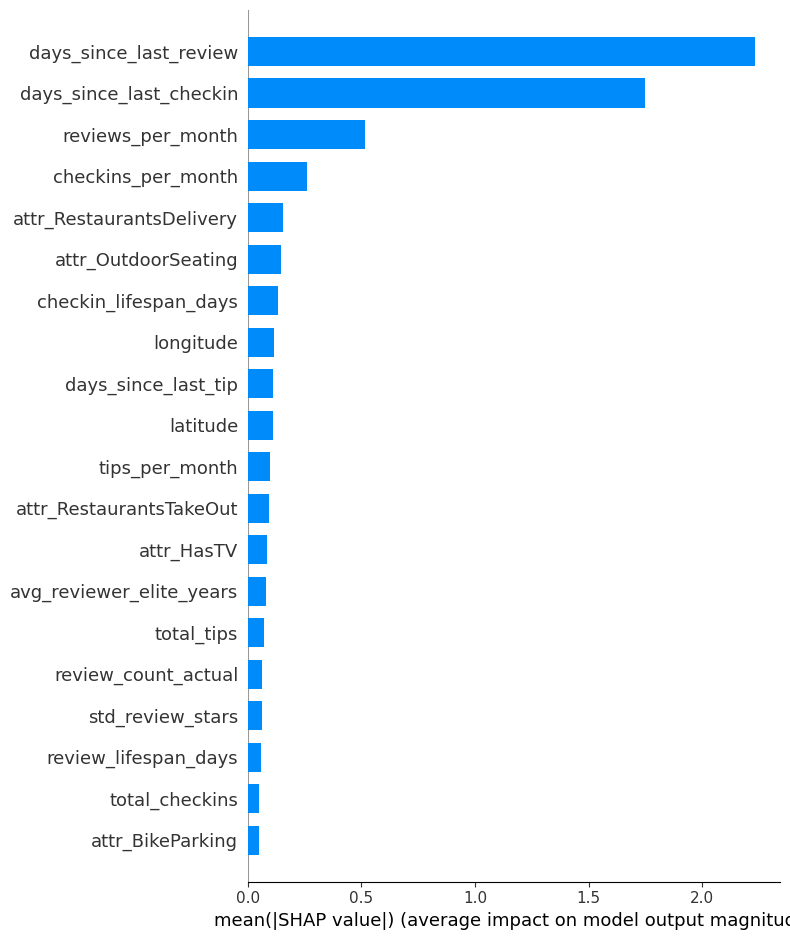

In [22]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20)

CROSS VALIDATION TESTING

In [23]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
print(scores)
print(f"Mean AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")

[0.98125233 0.98190695 0.98147036 0.98143271 0.98300587]
Mean AUC: 0.9818 (+/- 0.0006)


EXTRACTING THE HELD OUT DATA FROM BUSINESS_Y_REMOVED

In [24]:
holdout = raw_business[raw_business['is_open'].isna()].reset_index(drop=True)
print(holdout.shape)
print(business.shape)

(30069, 14)
(56293, 44)


In [25]:
# Extract holdout — businesses with unknown is_open status
holdout = raw_business[raw_business['is_open'].isna()].copy()
holdout = holdout[holdout['categories'].str.contains(pattern, na=False, case=False)]
holdout = holdout.reset_index(drop=True)
print(f"Holdout shape: {holdout.shape}")

Holdout shape: (14043, 14)


In [26]:
# Filter other files to holdout business ids
holdout_ids = set(holdout['business_id'])
holdout_reviews = raw_review[raw_review['business_id'].isin(holdout_ids)]
holdout_checkins = raw_checkin[raw_checkin['business_id'].isin(holdout_ids)]
holdout_tips = raw_tips[raw_tips['business_id'].isin(holdout_ids)]
holdout_users = raw_user[raw_user['user_id'].isin(set(holdout_reviews['user_id']))]

print(holdout_reviews.shape, holdout_checkins.shape, holdout_tips.shape, holdout_users.shape)

(1062892, 9) (13695, 2) (149917, 5) (543543, 22)


In [27]:
# Reviews
holdout_reviews['date'] = pd.to_datetime(holdout_reviews['date'])

holdout_review_features = holdout_reviews.groupby('business_id').agg(
    review_count_actual   = ('review_id', 'count'),
    avg_review_stars      = ('stars', 'mean'),
    std_review_stars      = ('stars', 'std'),
    total_useful          = ('useful', 'sum'),
    total_funny           = ('funny', 'sum'),
    total_cool            = ('cool', 'sum'),
    first_review_date     = ('date', 'min'),
    last_review_date      = ('date', 'max'),
).reset_index()

holdout_review_features['days_since_last_review'] = (reference_date - holdout_review_features['last_review_date']).dt.days
holdout_review_features['review_lifespan_days'] = (holdout_review_features['last_review_date'] - holdout_review_features['first_review_date']).dt.days
holdout_review_features['reviews_per_month'] = (
    holdout_review_features['review_count_actual'] / 
    (holdout_review_features['review_lifespan_days'] / 30)
).replace([float('inf')], 0)
holdout_review_features = holdout_review_features.drop(columns=['first_review_date', 'last_review_date'])

# Checkins
holdout_checkins['date'] = holdout_checkins['date'].str.split(', ')
holdout_checkins['date'] = holdout_checkins['date'].apply(lambda x: pd.to_datetime(x, errors='coerce'))

holdout_checkin_features = holdout_checkins.apply(lambda row: pd.Series({
    'business_id'             : row['business_id'],
    'total_checkins'          : len(row['date']),
    'days_since_last_checkin' : (reference_date - max(row['date'])).days,
    'checkin_lifespan_days'   : (max(row['date']) - min(row['date'])).days,
    'checkins_per_month'      : len(row['date']) / max((max(row['date']) - min(row['date'])).days / 30, 1)
}), axis=1)

# Tips
holdout_tips['date'] = pd.to_datetime(holdout_tips['date'])

holdout_tip_features = holdout_tips.groupby('business_id').agg(
    total_tips            = ('user_id', 'count'),
    total_compliments     = ('compliment_count', 'sum'),
    days_since_last_tip   = ('date', lambda x: (reference_date - x.max()).days),
    tip_lifespan_days     = ('date', lambda x: (x.max() - x.min()).days),
).reset_index()
holdout_tip_features['tips_per_month'] = (
    holdout_tip_features['total_tips'] /
    (holdout_tip_features['tip_lifespan_days'] / 30)
).replace([float('inf')], 0)

# Users
holdout_users['elite_years'] = holdout_users['elite'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) and x != '' and x != 'None' else 0
)
holdout_users['yelping_since'] = pd.to_datetime(holdout_users['yelping_since'])
holdout_users['yelping_experience_days'] = (reference_date - holdout_users['yelping_since']).dt.days

holdout_user_features_raw = holdout_users[['user_id', 'elite_years', 'fans', 'useful', 'review_count', 'yelping_experience_days']]
holdout_reviews_with_users = holdout_reviews[['business_id', 'user_id']].merge(holdout_user_features_raw, on='user_id', how='left')

holdout_user_features = holdout_reviews_with_users.groupby('business_id').agg(
    avg_reviewer_elite_years = ('elite_years', 'mean'),
    pct_elite_reviewers      = ('elite_years', lambda x: (x > 0).mean()),
    avg_reviewer_fans        = ('fans', 'mean'),
    avg_reviewer_useful      = ('useful', 'mean'),
    unique_reviewers         = ('user_id', 'nunique'),
).reset_index()

print("Feature engineering complete")

Feature engineering complete


In [28]:
holdout['attributes_parsed'] = holdout['attributes'].apply(parse_attributes)

for attr in bool_attrs:
    holdout[f'attr_{attr}'] = holdout['attributes_parsed'].apply(lambda x: parse_bool(x.get(attr)))

holdout['attr_PriceRange'] = holdout['attributes_parsed'].apply(
    lambda x: int(x['RestaurantsPriceRange2']) 
    if x.get('RestaurantsPriceRange2') not in [None, 'None'] 
    else np.nan
)

for attr in cat_attrs:
    cleaned = holdout['attributes_parsed'].apply(lambda x: clean_cat(x.get(attr)))
    dummies = pd.get_dummies(cleaned, prefix=f'attr_{attr}', dummy_na=False).astype(int)
    holdout = pd.concat([holdout, dummies], axis=1)

holdout = holdout.loc[:, ~holdout.columns.duplicated()]
print(f"Holdout after attributes: {holdout.shape}")

Holdout after attributes: (14043, 44)


In [29]:
attr_cols_holdout = [c for c in holdout.columns if c.startswith('attr_')]

holdout_final = holdout[['business_id', 'stars', 'review_count', 
                          'latitude', 'longitude'] + attr_cols_holdout].copy()

holdout_final = holdout_final.merge(holdout_review_features, on='business_id', how='left')
holdout_final = holdout_final.merge(holdout_checkin_features, on='business_id', how='left')
holdout_final = holdout_final.merge(holdout_tip_features, on='business_id', how='left')
holdout_final = holdout_final.merge(holdout_user_features, on='business_id', how='left')

print(f"Holdout final shape: {holdout_final.shape}")

Holdout final shape: (14043, 57)


In [30]:
print("Columns in X but not holdout:", set(X.columns) - set(holdout_final.columns))
print("Columns in holdout but not X:", set(holdout_final.columns) - set(X.columns) - {'business_id'})

Columns in X but not holdout: set()
Columns in holdout but not X: set()


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

ROC-AUC: 0.9809


In [32]:
print(sorted(X.columns.tolist()))
print(sorted(holdout_final.drop(columns=['business_id']).columns.tolist()))

['attr_Alcohol_beer_and_wine', 'attr_Alcohol_full_bar', 'attr_Alcohol_none', 'attr_BikeParking', 'attr_BusinessAcceptsCreditCards', 'attr_Caters', 'attr_DogsAllowed', 'attr_DriveThru', 'attr_GoodForKids', 'attr_HappyHour', 'attr_HasTV', 'attr_NoiseLevel_average', 'attr_NoiseLevel_loud', 'attr_NoiseLevel_quiet', 'attr_NoiseLevel_very_loud', 'attr_OutdoorSeating', 'attr_PriceRange', 'attr_RestaurantsAttire_casual', 'attr_RestaurantsAttire_dressy', 'attr_RestaurantsAttire_formal', 'attr_RestaurantsDelivery', 'attr_RestaurantsGoodForGroups', 'attr_RestaurantsReservations', 'attr_RestaurantsTableService', 'attr_RestaurantsTakeOut', 'attr_WheelchairAccessible', 'attr_WiFi_free', 'attr_WiFi_no', 'attr_WiFi_paid', 'avg_review_stars', 'avg_reviewer_elite_years', 'avg_reviewer_fans', 'avg_reviewer_useful', 'checkin_lifespan_days', 'checkins_per_month', 'days_since_last_checkin', 'days_since_last_review', 'days_since_last_tip', 'latitude', 'longitude', 'pct_elite_reviewers', 'review_count', 'revi

In [33]:
X_holdout = holdout_final[X.columns]

holdout_predictions = model.predict(X_holdout)
holdout_probabilities = model.predict_proba(X_holdout)[:, 1]

results = pd.DataFrame({
    'business_id': holdout_final['business_id'],
    'predicted_is_open': holdout_predictions,
    'probability_open': holdout_probabilities
})

print(results['predicted_is_open'].value_counts())
results.to_csv('holdout_predictions.csv', index=False)

predicted_is_open
1    9884
0    4159
Name: count, dtype: int64


DASHBOARD CREATION


In [34]:
# Find a well-reviewed restaurant to demo the dashboard
sample = final_df[final_df['review_count_actual'] > 200].iloc[0]
sample_id = sample['business_id']
sample_name = business[business['business_id'] == sample_id]['name'].values[0]

print(f"Demo restaurant: {sample_name}")
print(f"Business ID: {sample_id}")

Demo restaurant: BAP
Business ID: ROeacJQwBeh05Rqg7F6TCg


In [35]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Get sample restaurant data
sample_reviews = reviews[reviews['business_id'] == sample_id].copy()
sample_reviews['date'] = pd.to_datetime(sample_reviews['date'])
sample_reviews['month'] = sample_reviews['date'].dt.to_period('M').dt.to_timestamp()

sample_checkins = checkins[checkins['business_id'] == sample_id].copy()
sample_tips = tips[tips['business_id'] == sample_id].copy()
sample_tips['date'] = pd.to_datetime(sample_tips['date'])
sample_tips['month'] = sample_tips['date'].dt.to_period('M').dt.to_timestamp()

# Monthly aggregations
monthly_reviews = sample_reviews.groupby('month').agg(
    review_count = ('review_id', 'count'),
    avg_stars    = ('stars', 'mean'),
    total_useful = ('useful', 'sum'),
    total_funny  = ('funny', 'sum'),
    total_cool   = ('cool', 'sum')
).reset_index()

monthly_tips = sample_tips.groupby('month').agg(
    tip_count         = ('user_id', 'count'),
    total_compliments = ('compliment_count', 'sum')
).reset_index()

# Parse checkin timestamps
sample_checkin_row = checkins[checkins['business_id'] == sample_id]
if len(sample_checkin_row) > 0:
    checkin_dates = pd.to_datetime(
        sample_checkin_row.iloc[0]['date'], errors='coerce'
    )
    checkin_df = pd.DataFrame({'date': checkin_dates})
    checkin_df['month'] = checkin_df['date'].dt.to_period('M').dt.to_timestamp()
    monthly_checkins = checkin_df.groupby('month').size().reset_index(name='checkin_count')
else:
    monthly_checkins = pd.DataFrame(columns=['month', 'checkin_count'])

# Competitor comparison
city = business[business['business_id'] == sample_id]['city'].values[0]
competitors = final_df[final_df['business_id'].isin(
    business[business['city'] == city]['business_id']
)]

# 5 Key Metrics
avg_stars     = sample_reviews['stars'].mean()
reviews_month = len(sample_reviews) / max((sample_reviews['date'].max() - sample_reviews['date'].min()).days / 30, 1)
pct_positive  = (sample_reviews['stars'] >= 4).mean() * 100
total_checkin = len(checkin_df) if len(sample_checkin_row) > 0 else 0
days_since    = (reference_date - sample_reviews['date'].max()).days

print(f"⭐ Avg Star Rating:        {avg_stars:.2f}")
print(f"📈 Reviews per Month:      {reviews_month:.1f}")
print(f"👍 % Positive Reviews:     {pct_positive:.1f}%")
print(f"🚶 Total Checkins:         {total_checkin}")
print(f"📅 Days Since Last Review: {days_since}")

⭐ Avg Star Rating:        4.32
📈 Reviews per Month:      2.1
👍 % Positive Reviews:     81.7%
🚶 Total Checkins:         221
📅 Days Since Last Review: 5


In [38]:
fig = make_subplots(
    rows=4, cols=2,
    subplot_titles=(
        '1. Star Rating Distribution',
        '2. Review Volume Over Time',
        '3. Average Rating Over Time',
        '4. Engagement Votes Over Time',
        '5. Checkin Frequency Over Time',
        '6. Rating vs Review Count (vs Competitors)',
        '7. Feature Importance (SHAP)',
        '8. Tip Compliments Over Time'
    ),
    vertical_spacing=0.12,
    horizontal_spacing=0.1
)

# 1. Star Rating Distribution
star_counts = sample_reviews['stars'].value_counts().sort_index()
fig.add_trace(go.Bar(
    x=star_counts.index.astype(str),
    y=star_counts.values,
    marker_color=['#ef4444','#f97316','#eab308','#84cc16','#22c55e'],
    name='Star Distribution'
), row=1, col=1)

# 2. Review Volume Over Time
fig.add_trace(go.Scatter(
    x=monthly_reviews['month'],
    y=monthly_reviews['review_count'],
    mode='lines+markers',
    line=dict(color='#3b82f6'),
    name='Reviews/Month'
), row=1, col=2)

# 3. Average Rating Over Time
fig.add_trace(go.Scatter(
    x=monthly_reviews['month'],
    y=monthly_reviews['avg_stars'],
    mode='lines+markers',
    line=dict(color='#f59e0b'),
    name='Avg Rating'
), row=2, col=1)
fig.add_hline(y=avg_stars, line_dash='dash', line_color='gray', row=2, col=1)

# 4. Engagement Votes Over Time
fig.add_trace(go.Scatter(x=monthly_reviews['month'], y=monthly_reviews['total_useful'],
    mode='lines', name='Useful', line=dict(color='#8b5cf6')), row=2, col=2)
fig.add_trace(go.Scatter(x=monthly_reviews['month'], y=monthly_reviews['total_funny'],
    mode='lines', name='Funny', line=dict(color='#ec4899')), row=2, col=2)
fig.add_trace(go.Scatter(x=monthly_reviews['month'], y=monthly_reviews['total_cool'],
    mode='lines', name='Cool', line=dict(color='#06b6d4')), row=2, col=2)

# 5. Checkin Frequency Over Time
if len(monthly_checkins) > 0:
    fig.add_trace(go.Bar(
        x=monthly_checkins['month'],
        y=monthly_checkins['checkin_count'],
        marker_color='#10b981',
        name='Checkins'
    ), row=3, col=1)

# 6. Rating vs Review Count (vs Competitors)
fig.add_trace(go.Scatter(
    x=competitors['review_count_actual'],
    y=competitors['avg_review_stars'],
    mode='markers',
    marker=dict(color='#94a3b8', size=4, opacity=0.5),
    name='Competitors'
), row=3, col=2)
fig.add_trace(go.Scatter(
    x=[sample['review_count_actual']],
    y=[sample['avg_review_stars']],
    mode='markers',
    marker=dict(color='#ef4444', size=12, symbol='star'),
    name=sample_name
), row=3, col=2)

# 7. SHAP Feature Importance
shap_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=True).tail(15)

fig.add_trace(go.Bar(
    x=shap_importance['importance'],
    y=shap_importance['feature'],
    orientation='h',
    marker_color='#6366f1',
    name='SHAP Importance'
), row=4, col=1)

# 8. Tip Compliments Over Time
if len(monthly_tips) > 0:
    fig.add_trace(go.Bar(
        x=monthly_tips['month'],
        y=monthly_tips['total_compliments'],
        marker_color='#f43f5e',
        name='Compliments'
    ), row=4, col=2)

# Layout
fig.update_layout(
    title=dict(
        text=f'Restaurant Performance Dashboard — {sample_name}',
        font=dict(size=20)
    ),
    height=1400,
    showlegend=False,
    template='plotly_white'
)

fig.show()
fig.write_html('dashboard.html')
print("Dashboard saved to dashboard.html")

Dashboard saved to dashboard.html
